# Rethinking Chicago Crime Analysis

## Introduction

In this analysis, we will explore the crime data of Chicago to identify patterns and trends. We will use various data visualization techniques to gain insights into the types of crimes, their locations, and the times they occur.

## Data Collection

> Thanks to These projects:
> - https://www.kaggle.com/fahd09/eda-of-crime-in-chicago-2005-2016
> - 朱小波, 李昕, 叶信岳. 数据关联背景下芝加哥市一般盗窃案件的多维度分析[J]. 犯罪研究, 2018(4):10.

## Data Loading and Cleaning

Before we can analyze the data, we need to preprocess it. This includes handling missing values, converting data types, and creating new features if necessary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gc

In [20]:
pd.set_option('display.max_columns', None)

In [ ]:
Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn", low_memory=False)
Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn", low_memory=False)
Crime_2008_to_2011 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2008_to_2011.csv", on_bad_lines="warn", low_memory=False)
Crime_2012_to_2017 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2012_to_2017.csv", on_bad_lines="warn", low_memory=False)

/tmp/ipykernel_331292/1137305216.py:1: ParserWarning: Skipping line 1513591: expected 23 fields, saw 24

  Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn")
/tmp/ipykernel_331292/1137305216.py:1: DtypeWarning: Columns (0: Y Coordinate, 1: Latitude) have mixed types. Specify dtype option on import or set low_memory=False.
  Crime_2001_to_2004 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2001_to_2004.csv", on_bad_lines="warn")
/tmp/ipykernel_331292/1137305216.py:2: ParserWarning: Skipping line 533719: expected 23 fields, saw 24

  Crime_2005_to_2007 = pd.read_csv("../Data/Crimes in Chicago_An extensive dataset of crimes in Chicago (2001-2017), by City of Chicago/Chicago_Crimes_2005_to_2007.csv", on_bad_lines="warn")
/tmp/ipykernel_331292/1137305216.py:3: ParserWarning

Verify all dataframes have the same columns

In [3]:
print(Crime_2001_to_2004.columns)
print(Crime_2005_to_2007.columns)
print(Crime_2008_to_2011.columns)
print(Crime_2012_to_2017.columns)

print("All dataframes have the same columns: ",
      set(Crime_2001_to_2004.columns) == set(Crime_2005_to_2007.columns) == set(Crime_2008_to_2011.columns) == set(Crime_2012_to_2017.columns))


Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='str')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location'],
      dtype='str')
Index(['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR',
       'Primary Type', 'Description', 'Location Description', 'Arrest',
       'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code',
       'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude',
       'Longitude', 'Location

Combine all dataframes into one for easier analysis

In [4]:
Crime_data = pd.concat([Crime_2001_to_2004, Crime_2005_to_2007, Crime_2008_to_2011, Crime_2012_to_2017], ignore_index=True)
del Crime_2001_to_2004
del Crime_2005_to_2007
del Crime_2008_to_2011
del Crime_2012_to_2017
gc.collect()
Crime_data.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,879,4786321,HM399414,01/01/2004 12:01:00 AM,082XX S COLES AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,...,7.0,46.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,2544,4676906,HM278933,03/01/2003 12:00:00 AM,004XX W 42ND PL,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,False,...,11.0,61.0,26,1173974.0,1876757.0,2003.0,04/15/2016 08:55:02 AM,41.817229,-87.637328,"(41.817229156, -87.637328162)"
2,2919,4789749,HM402220,06/20/2004 11:00:00 AM,025XX N KIMBALL AVE,1752,OFFENSE INVOLVING CHILDREN,AGG CRIM SEX ABUSE FAM MEMBER,RESIDENCE,False,...,35.0,22.0,20,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
3,2927,4789765,HM402058,12/30/2004 08:00:00 PM,045XX W MONTANA ST,0840,THEFT,FINANCIAL ID THEFT: OVER $300,OTHER,False,...,31.0,20.0,06,NaN,NaN,2004.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
4,3302,4677901,HM275615,05/01/2003 01:00:00 AM,111XX S NORMAL AVE,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,...,34.0,49.0,06,1174948.0,1831051.0,2003.0,04/15/2016 08:55:02 AM,41.691785,-87.635116,"(41.691784636, -87.635115968)"


Handle duplicate entries

In [5]:
print("Before handling duplicates: ", Crime_data.shape)
Crime_data.drop_duplicates(inplace=True)
print("After handling duplicates: ", Crime_data.shape)

Before handling duplicates:  (7941282, 23)
After handling duplicates:  (6200659, 23)


Convert 'Date' column to datetime format

In [6]:
Crime_data['Date'] = pd.to_datetime(Crime_data['Date'], format="%m/%d/%Y %I:%M:%S %p")

In [7]:
Crime_data.dtypes

Unnamed: 0                       int64
ID                               int64
Case Number                        str
Date                    datetime64[us]
Block                              str
IUCR                               str
Primary Type                       str
Description                        str
Location Description               str
Arrest                            bool
Domestic                          bool
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                           str
X Coordinate                   float64
Y Coordinate                    object
Year                           float64
Updated On                         str
Latitude                        object
Longitude                      float64
Location                           str
dtype: object

## Exploratory Data Analysis

### Are IDs unique?

In [8]:
# Count cases with the same id and their counts
id_counts = Crime_data['ID'].value_counts()
duplicate_ids = id_counts[id_counts > 1]
print(f"Number of duplicate IDs: {len(duplicate_ids)}")
print(duplicate_ids.head())

Number of duplicate IDs: 29847
ID
1384626    2
1384627    2
1384628    2
1384629    2
1384630    2
Name: count, dtype: int64


In [24]:
# Display these duplicate IDs and their corresponding rows, sorted by ID
duplicate_rows = Crime_data[Crime_data['ID'].isin(duplicate_ids.index)].sort_values(by='ID')
duplicate_rows.iloc[90:96]

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
1572870,3599605,1384633,G091984,2001-02-14 07:01:00,010XX N STATE ST,051A,ASSAULT,AGGRAVATED: HANDGUN,RESIDENCE,False,False,1824,18.0,NaN,NaN,04A,1176133.0,1907471.0,2001.0,08/17/2015 03:03:40 PM,41.9014622,-87.628483,"(41.9014622, -87.628483472)"
59281,3599605,1384633,G091984,2001-02-14 07:01:00,010XX N STATE ST,051A,ASSAULT,AGGRAVATED: HANDGUN,RESIDENCE,False,False,1824,18.0,NaN,NaN,04A,1176133.0,1907471.0,2001.0,08/17/2015 03:03:40 PM,41.901462,-87.628483,"(41.9014622, -87.628483472)"
1572871,3599606,1384634,G095137,2001-02-15 20:45:00,045XX W CHICAGO AV,0810,THEFT,OVER $500,PARKING LOT/GARAGE(NON.RESID.),False,False,1111,11.0,NaN,NaN,06,1145899.0,1904970.0,2001.0,08/17/2015 03:03:40 PM,41.895227143,-87.739600,"(41.895227143, -87.739600255)"
59282,3599606,1384634,G095137,2001-02-15 20:45:00,045XX W CHICAGO AV,0810,THEFT,OVER $500,PARKING LOT/GARAGE(NON.RESID.),False,False,1111,11.0,NaN,NaN,06,1145899.0,1904970.0,2001.0,08/17/2015 03:03:40 PM,41.895227,-87.739600,"(41.895227143, -87.739600255)"
1572872,3599607,1384635,G093992,2001-02-15 12:25:00,068XX S ANTHONY AV,1310,CRIMINAL DAMAGE,TO PROPERTY,SIDEWALK,False,False,322,3.0,NaN,NaN,14,1180445.0,1859578.0,2001.0,08/17/2015 03:03:40 PM,41.769942143,-87.614118,"(41.769942143, -87.614118188)"
59283,3599607,1384635,G093992,2001-02-15 12:25:00,068XX S ANTHONY AV,1310,CRIMINAL DAMAGE,TO PROPERTY,SIDEWALK,False,False,322,3.0,NaN,NaN,14,1180445.0,1859578.0,2001.0,08/17/2015 03:03:40 PM,41.769942,-87.614118,"(41.769942143, -87.614118188)"


In [21]:
# view id==1385

duplicate_id_1385 = Crime_data[Crime_data['ID'] == 1385]
print(duplicate_id_1385)

         Unnamed: 0    ID Case Number                Date  \
59511       3599835  1385    HH233509 2002-03-10 14:20:00   
1573100     3599835  1385    HH233509 2002-03-10 14:20:00   

                             Block  IUCR Primary Type          Description  \
59511    093XX S COTTAGE GROVE AVE  0110     HOMICIDE  FIRST DEGREE MURDER   
1573100  093XX S COTTAGE GROVE AVE  0110     HOMICIDE  FIRST DEGREE MURDER   

        Location Description  Arrest  Domestic  Beat  District  Ward  \
59511                  HOUSE    True     False   633       6.0   9.0   
1573100                HOUSE    True     False   633       6.0   9.0   

         Community Area FBI Code  X Coordinate Y Coordinate    Year  \
59511              44.0      01A     1183195.0    1843194.0  2002.0   
1573100            44.0      01A     1183195.0    1843194.0  2002.0   

                     Updated On     Latitude  Longitude  \
59511    08/17/2015 03:03:40 PM    41.724919 -87.604547   
1573100  08/17/2015 03:03:40 PM 

### Types of Crimes

In [11]:
unique_crimes = Crime_data['Primary Type'].unique().tolist()
print(f"Total unique crime types: {len(unique_crimes)}")
print(unique_crimes)

Total unique crime types: 35
['THEFT', 'OTHER OFFENSE', 'OFFENSE INVOLVING CHILDREN', 'CRIM SEXUAL ASSAULT', 'MOTOR VEHICLE THEFT', 'SEX OFFENSE', 'DECEPTIVE PRACTICE', 'BATTERY', 'BURGLARY', 'WEAPONS VIOLATION', 'PUBLIC PEACE VIOLATION', 'NARCOTICS', 'GAMBLING', 'PROSTITUTION', 'LIQUOR LAW VIOLATION', 'INTERFERENCE WITH PUBLIC OFFICER', 'CRIMINAL DAMAGE', 'ASSAULT', 'STALKING', 'ARSON', 'CRIMINAL TRESPASS', 'HOMICIDE', 'ROBBERY', 'OBSCENITY', 'KIDNAPPING', 'INTIMIDATION', 'RITUALISM', 'DOMESTIC VIOLENCE', 'OTHER NARCOTIC VIOLATION', 'PUBLIC INDECENCY', 'NON-CRIMINAL', 'HUMAN TRAFFICKING', 'CONCEALED CARRY LICENSE VIOLATION', 'NON - CRIMINAL', 'NON-CRIMINAL (SUBJECT SPECIFIED)']


Primary Type
THEFT                                1290528
BATTERY                              1131424
CRIMINAL DAMAGE                       713582
NARCOTICS                             677868
OTHER OFFENSE                         383846
ASSAULT                               378834
BURGLARY                              363098
MOTOR VEHICLE THEFT                   292641
ROBBERY                               234577
DECEPTIVE PRACTICE                    224147
CRIMINAL TRESPASS                     178915
PROSTITUTION                           65794
WEAPONS VIOLATION                      60907
PUBLIC PEACE VIOLATION                 44920
OFFENSE INVOLVING CHILDREN             40348
CRIM SEXUAL ASSAULT                    23720
SEX OFFENSE                            22734
GAMBLING                               13913
LIQUOR LAW VIOLATION                   13512
INTERFERENCE WITH PUBLIC OFFICER       12886
ARSON                                  10352
HOMICIDE                                82

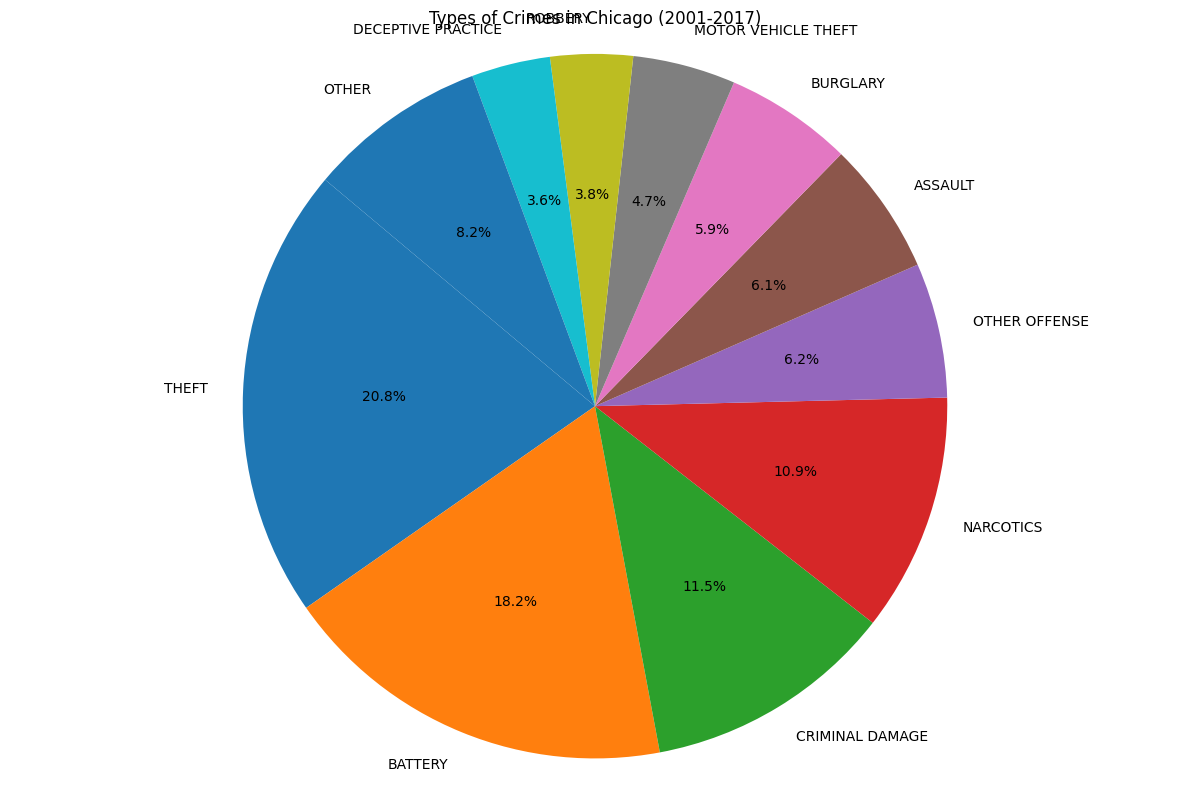

In [12]:
crime_counts = Crime_data['Primary Type'].value_counts()
print(crime_counts)

top_crimes = crime_counts.head(10)
other_count = crime_counts.iloc[10:].sum()
plot_data = pd.concat([top_crimes, pd.Series({'OTHER': other_count})])

plt.figure(figsize=(12, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=140)
plt.title('Types of Crimes in Chicago (2001-2017)')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Non-geographic Missing values?

In [13]:
# Check missing values across all columns
missing_counts = Crime_data.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": (missing_counts / len(Crime_data) * 100).round(2)
})

# Show only columns with missing values
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:\n")
print(missing_summary)

# Test whether missing data is only in geographic fields
geo_cols = {"X Coordinate", "Y Coordinate", "Latitude", "Longitude", "Location"}
non_geo_missing = [col for col in missing_summary.index if col not in geo_cols]

if not non_geo_missing:
    print("\nYes — missing values are only in geographic information columns.")
else:
    print("\nNo — there are missing values in non-geographic columns too:")
    print(non_geo_missing)

Columns with missing values:

                      missing_count  missing_pct
Community Area               645838        10.42
Ward                         644660        10.40
Location                      84224         1.36
Longitude                     84224         1.36
Latitude                      84223         1.36
X Coordinate                  84223         1.36
Y Coordinate                  84223         1.36
Location Description           1968         0.03
District                         49         0.00
Case Number                       4         0.00

No — there are missing values in non-geographic columns too:
['Community Area', 'Ward', 'Location Description', 'District', 'Case Number']


What are the case numbers that are missing?

In [14]:
missing_case_rows = Crime_data[Crime_data["Case Number"].isna()]

print(f"Number of missing case numbers: {len(missing_case_rows)}")
# missing_case_rows[["ID", "Date", "Block", "Primary Type", "Case Number"]]
missing_case_rows

Number of missing case numbers: 4


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4425181,1503746,7014449,NaN,2009-07-10 11:00:00,082XX S HARPER AVE,0560,ASSAULT,SIMPLE,STREET,False,...,8.0,45.0,08A,1187910.0,1850555.0,2009.0,02/04/2016 06:33:39 AM,41.745008,-87.587042,"(41.74500765, -87.587041972)"
4447882,1526447,7049552,NaN,2009-07-30 03:00:00,058XX N PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,...,40.0,77.0,14,1164170.0,1938694.0,2009.0,02/04/2016 06:33:39 AM,41.987401,-87.671539,"(41.987401038, -87.671539153)"
4809787,1888354,7610078,NaN,2010-07-16 14:56:00,005XX W VAN BUREN ST,0460,BATTERY,SIMPLE,SIDEWALK,True,...,2.0,28.0,08B,1172646.0,1898435.0,2010.0,02/04/2016 06:33:39 AM,41.876745,-87.641559,"(41.876744768, -87.641559043)"
7759089,5192747,8475075,NaN,2012-02-08 22:00:00,032XX N KILDARE AVE,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,...,31.0,16.0,05,NaN,NaN,2012.0,05/04/2016 03:48:23 PM,NaN,NaN,NaN


### 